# Recommendation System - Hệ Thống Gợi Ý Phim

## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import TruncatedSVD
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# Thiết lập đường dẫn
BASE_DIR = Path.cwd().parent
INPUT_PATH = BASE_DIR / "outputs" / "data_split" / "train.csv"
TEST_PATH = BASE_DIR / "outputs" / "data_split" / "test.csv"
OUTPUT_DIR = BASE_DIR / "outputs" / "recommendation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load Dữ Liệu

In [ ]:
start_time = time.time()

# Đọc dữ liệu
train_df = pd.read_csv(INPUT_PATH)
test_df = pd.read_csv(TEST_PATH)

print(f"📊 Train set: {len(train_df):,} interactions")
print(f"📊 Test set: {len(test_df):,} interactions")
print(f"\n👥 Users: {train_df['user_id'].nunique():,}")
print(f"🎬 Movies: {train_df['movie_id'].nunique():,}")

📊 Train set: 6,862 interactions
📊 Test set: 1,992 interactions

👥 Users: 2,454
🎬 Movies: 2,305


In [ ]:
# Hiển thị mẫu dữ liệu
train_df.head()

,user_id,movie_id,movie_title,rating,cast,release_year,language,genres_list,primary_genre,genre_count,...,genre_thriller,genre_tv_movie,genre_war,genre_western,primary_genre_encoded,user_idx,movie_idx,source_encoded,year_scaled,genre_count_scaled
0,Sejian,1265609,War Machine,6.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,779,741,0,1.0,0.333333
1,MovieGuys,1265609,War Machine,6.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,600,741,0,1.0,0.333333
2,Dean,1265609,War Machine,9.0,"Alan Ritchson, Dennis Quaid, Stephan James",2026,en,"[""action"", ""science fiction"", ""thriller""]",action,3,...,1,0,0,0,0,248,741,0,1.0,0.333333
3,MovieGuys,1290821,Shelter,6.0,"Jason Statham, Bodhi Rae Breathnach, Michael S...",2026,en,"[""action"", ""crime"", ""thriller""]",action,3,...,1,0,0,0,0,600,797,0,1.0,0.333333
4,Kashifzia,799882,The Bluff,6.0,"Priyanka Chopra Jonas, Karl Urban, Safia Oakle...",2026,en,"[""action"", ""thriller""]",action,2,...,1,0,0,0,0,473,2283,0,1.0,0.166667


## 3. Tạo User-Item Matrix

Chuyển đổi dữ liệu thành ma trận user-item với giá trị là rating.

In [ ]:
# Tạo pivot table
print("🔨 Đang tạo User-Item matrix...")
user_item_matrix = train_df.pivot_table(
    index='user_id', 
    columns='movie_id', 
    values='rating'
).fillna(0)

print(f"✅ Matrix shape: {user_item_matrix.shape}")
print(f"   {user_item_matrix.shape[0]} users x {user_item_matrix.shape[1]} movies")
print(f"\n📊 Sparsity: {(user_item_matrix == 0).sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]) * 100:.2f}%")

In [ ]:
# Hiển thị một phần của matrix
user_item_matrix.iloc[:10, :10]

## 4. Matrix Factorization với TruncatedSVD

Phân rã ma trận thành user factors và item factors.

In [ ]:
# Xác định số factors
n_factors = min(50, user_item_matrix.shape[1] - 1)
print(f"🎯 Số factors: {n_factors}")

🎯 Số factors: 50


In [ ]:
# Huấn luyện SVD
print("🔍 Đang huấn luyện TruncatedSVD...")
svd = TruncatedSVD(n_components=n_factors, random_state=42)

# User Factors (U * Sigma)
user_factors_matrix = svd.fit_transform(user_item_matrix)

# Item Factors (V^T)
item_factors_matrix = svd.components_.T

print(f"✅ SVD đã được huấn luyện")
print(f"   User factors shape: {user_factors_matrix.shape}")
print(f"   Item factors shape: {item_factors_matrix.shape}")

🔍 Đang huấn luyện TruncatedSVD...
✅ SVD đã được huấn luyện
   User factors shape: (2454, 50)
   Item factors shape: (2305, 50)


In [ ]:
# Phân tích explained variance
explained_variance = svd.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"📊 Explained Variance:")
print(f"   Total: {cumulative_variance[-1]*100:.2f}%")
print(f"   Top 10 components: {cumulative_variance[9]*100:.2f}%")

📊 Explained Variance:
   Total: 50.83%
   Top 10 components: 30.55%


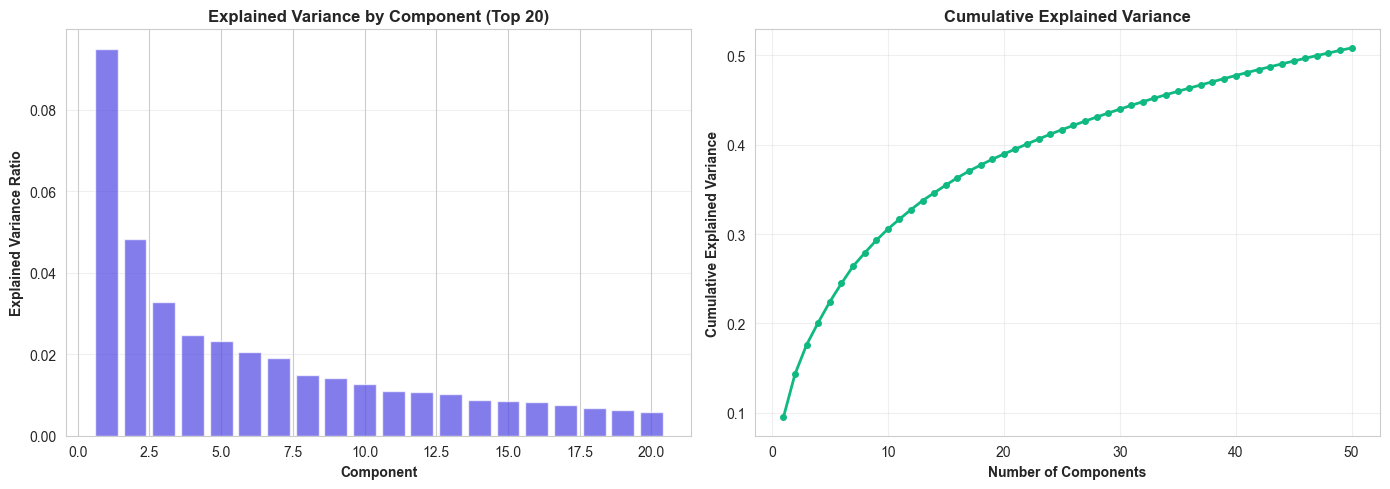

In [ ]:
# Visualization: Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Individual variance
axes[0].bar(range(1, min(21, len(explained_variance)+1)), 
           explained_variance[:20], color='#4f46e5', alpha=0.7)
axes[0].set_xlabel('Component', fontweight='bold')
axes[0].set_ylabel('Explained Variance Ratio', fontweight='bold')
axes[0].set_title('Explained Variance by Component (Top 20)', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Subplot 2: Cumulative variance
axes[1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, 
            marker='o', color='#10b981', linewidth=2, markersize=4)
axes[1].set_xlabel('Number of Components', fontweight='bold')
axes[1].set_ylabel('Cumulative Explained Variance', fontweight='bold')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "svd_variance.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Tạo Recommendations

Tạo danh sách gợi ý top-K cho mỗi user.

In [ ]:
# Lấy sample users để demo
sample_users = user_item_matrix.index[:50]
print(f"🎯 Tạo recommendations cho {len(sample_users)} users...")

🎯 Tạo recommendations cho 50 users...


In [ ]:
# Dự đoán ratings (Reconstruct matrix)
predicted_ratings = np.dot(user_factors_matrix[:50], item_factors_matrix.T)

print(f"✅ Predicted ratings shape: {predicted_ratings.shape}")

✅ Predicted ratings shape: (50, 2305)


In [ ]:
# Tạo movie title dictionary
movie_titles = train_df[['movie_id', 'movie_title']].drop_duplicates().set_index('movie_id')['movie_title'].to_dict()

print(f"📚 Movie dictionary: {len(movie_titles)} movies")

📚 Movie dictionary: 2305 movies


In [ ]:
# Tạo recommendation lists
rec_list_data = []

for i, user_id in enumerate(sample_users):
    user_preds = predicted_ratings[i]
    
    # Lấy top 10 phim có điểm cao nhất
    top_indices = np.argsort(user_preds)[::-1][:10]
    
    for rank, idx in enumerate(top_indices, 1):
        movie_id = user_item_matrix.columns[idx]
        rec_list_data.append({
            "user_id": user_id,
            "movie_id": int(movie_id),
            "movie_title": movie_titles.get(movie_id, "Unknown"),
            "score": round(float(user_preds[idx]), 2),
            "rank": rank
        })

rec_lists_df = pd.DataFrame(rec_list_data)
print(f"✅ Đã tạo {len(rec_lists_df)} recommendations")
rec_lists_df.head(20)

✅ Đã tạo 500 recommendations


,user_id,movie_id,movie_title,score,rank
0,(not) mAk1ko,1128212,The Last Rodeo,0.09,1
1,(not) mAk1ko,1103676,The Mastermind,0.08,2
2,(not) mAk1ko,1081550,"Sorry, Baby",0.08,3
3,(not) mAk1ko,912836,Marshmallow,0.08,4
4,(not) mAk1ko,1079176,Sketch,0.08,5
5,(not) mAk1ko,918266,Is This Thing On?,0.07,6
6,(not) mAk1ko,977463,Eleanor the Great,0.07,7
7,(not) mAk1ko,553090,Rust,0.07,8
8,(not) mAk1ko,701249,Peaky Blinders: The Immortal Man,0.07,9
9,(not) mAk1ko,1005440,A Big Bold Beautiful Journey,0.07,10


## 6. Đánh Giá Mô Hình

Tính RMSE trên tập train (demo).

In [ ]:
# Tính RMSE trên sample
actual = user_item_matrix.values[:50]
predicted = predicted_ratings

# Chỉ tính RMSE trên các giá trị khác 0 (đã có rating)
mask = actual != 0
mse = np.mean((actual[mask] - predicted[mask])**2)
rmse = np.sqrt(mse)

print(f"📊 Evaluation Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   MAE: {np.mean(np.abs(actual[mask] - predicted[mask])):.4f}")

📊 Evaluation Metrics:
   RMSE: 4.2633
   MAE: 2.9788


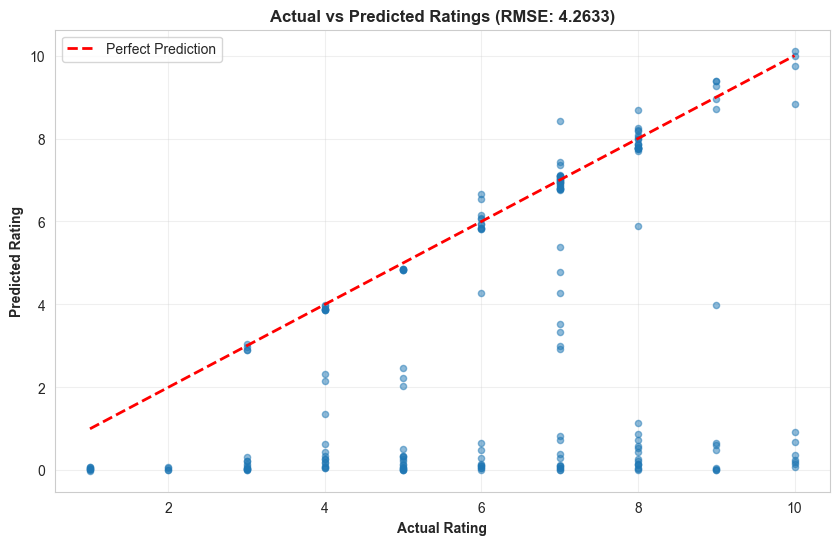

In [ ]:
# Visualization: Actual vs Predicted
plt.figure(figsize=(10, 6))
sample_size = min(1000, mask.sum())
sample_indices = np.random.choice(np.where(mask.flatten())[0], sample_size, replace=False)

actual_flat = actual.flatten()[sample_indices]
predicted_flat = predicted.flatten()[sample_indices]

plt.scatter(actual_flat, predicted_flat, alpha=0.5, s=20)
plt.plot([actual_flat.min(), actual_flat.max()], 
        [actual_flat.min(), actual_flat.max()], 
        'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Rating', fontweight='bold')
plt.ylabel('Predicted Rating', fontweight='bold')
plt.title(f'Actual vs Predicted Ratings (RMSE: {rmse:.4f})', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "prediction_accuracy.png", dpi=300, bbox_inches='tight')
plt.show()

## 7. Phân Tích Recommendations

In [ ]:
# Top recommended movies
top_movies = rec_lists_df['movie_title'].value_counts().head(10)

print("🏆 Top 10 Most Recommended Movies:")
for i, (movie, count) in enumerate(top_movies.items(), 1):
    print(f"   {i}. {movie}: {count} times")

🏆 Top 10 Most Recommended Movies:
   1. The Muppet Show: 9 times
   2. The Bad Guys 2: 7 times
   3. Nobody 2: 6 times
   4. Top Gun: Maverick: 6 times
   5. Good Fortune: 6 times
   6. Roofman: 5 times
   7. Is This Thing On?: 5 times
   8. Solo Mio: 5 times
   9. Playdate: 5 times
   10. Caught Stealing: 5 times


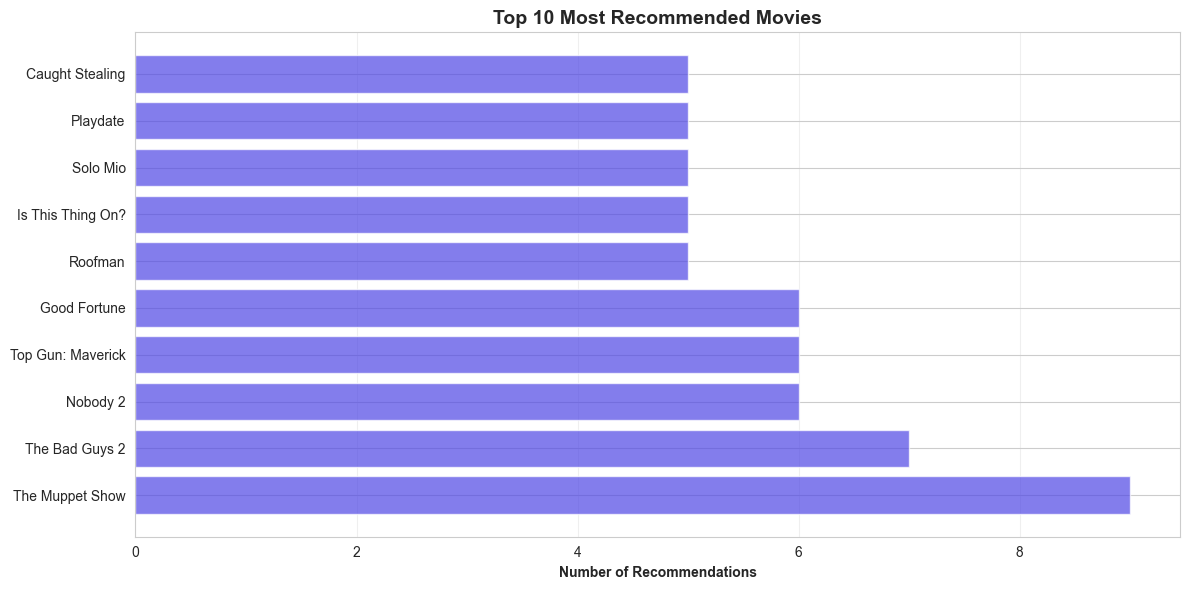

In [ ]:
# Visualization: Top recommended movies
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_movies)), top_movies.values, color='#4f46e5', alpha=0.7)
plt.yticks(range(len(top_movies)), [title[:40] + '...' if len(title) > 40 else title for title in top_movies.index])
plt.xlabel('Number of Recommendations', fontweight='bold')
plt.title('Top 10 Most Recommended Movies', fontweight='bold', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_recommendations.png", dpi=300, bbox_inches='tight')
plt.show()

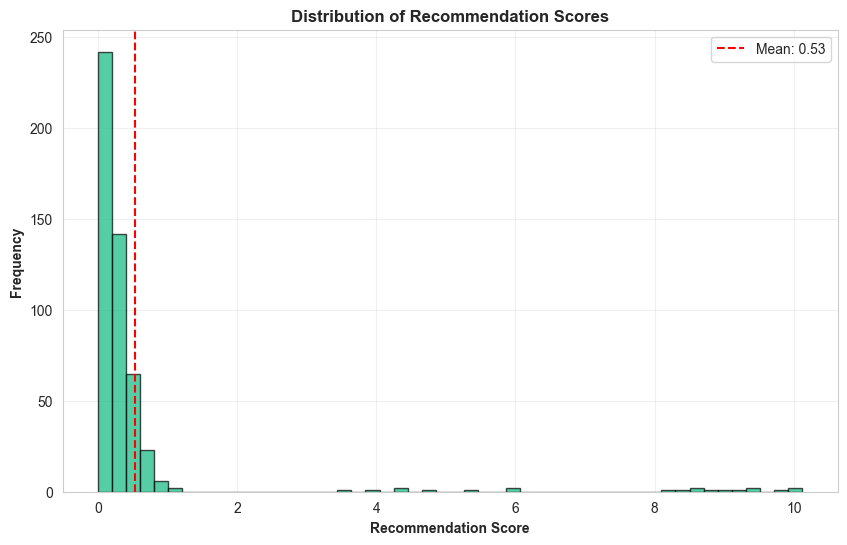

In [ ]:
# Score distribution
plt.figure(figsize=(10, 6))
plt.hist(rec_lists_df['score'], bins=50, color='#10b981', alpha=0.7, edgecolor='black')
plt.axvline(rec_lists_df['score'].mean(), color='red', linestyle='--', 
           label=f'Mean: {rec_lists_df["score"].mean():.2f}')
plt.xlabel('Recommendation Score', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.title('Distribution of Recommendation Scores', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_DIR / "score_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

## 8. Ví Dụ Recommendations cho User

In [ ]:
# Hiển thị recommendations cho 3 users đầu tiên
for user_id in sample_users[:3]:
    user_recs = rec_lists_df[rec_lists_df['user_id'] == user_id].head(10)
    
    print(f"\n{'='*80}")
    print(f"🎬 Recommendations for User {user_id}")
    print(f"{'='*80}")
    
    for _, row in user_recs.iterrows():
        print(f"   {row['rank']}. {row['movie_title'][:60]} (Score: {row['score']:.2f})")


🎬 Recommendations for User (not) mAk1ko
   1. The Last Rodeo (Score: 0.09)
   2. The Mastermind (Score: 0.08)
   3. Sorry, Baby (Score: 0.08)
   4. Marshmallow (Score: 0.08)
   5. Sketch (Score: 0.08)
   6. Is This Thing On? (Score: 0.07)
   7. Eleanor the Great (Score: 0.07)
   8. Rust (Score: 0.07)
   9. Peaky Blinders: The Immortal Man (Score: 0.07)
   10. A Big Bold Beautiful Journey (Score: 0.07)

🎬 Recommendations for User +schmoogie
   1. Deathstalker (Score: 0.26)
   2. Shelter (Score: 0.22)
   3. Dangerous Animals (Score: 0.22)
   4. EPiC: Elvis Presley in Concert (Score: 0.17)
   5. Relay (Score: 0.14)
   6. Long Distance (Score: 0.13)
   7. Redux Redux (Score: 0.13)
   8. Marshmallow (Score: 0.13)
   9. The Rip (Score: 0.11)
   10. Monster Island (Score: 0.11)

🎬 Recommendations for User -LBJ-
   1. Wicked (Score: 0.31)
   2. Bugonia (Score: 0.27)
   3. Sinners (Score: 0.26)
   4. Is This Thing On? (Score: 0.26)
   5. If I Had Legs I'd Kick You (Score: 0.26)
   6. Nuremberg

## 9. Lưu Kết Quả

In [ ]:
# Lưu User Factors (Parquet)
user_factors_df = pd.DataFrame(user_factors_matrix, index=user_item_matrix.index)
user_factors_df.columns = [f'factor_{i}' for i in range(n_factors)]
user_factors_df.to_parquet(OUTPUT_DIR / "user_factors.parquet", engine='pyarrow')
print("✅ Đã lưu user_factors.parquet")

In [ ]:
# Lưu Item Factors (Parquet)
item_factors_df = pd.DataFrame(item_factors_matrix, index=user_item_matrix.columns)
item_factors_df.columns = [f'factor_{i}' for i in range(n_factors)]
item_factors_df.to_parquet(OUTPUT_DIR / "item_factors.parquet", engine='pyarrow')
print("✅ Đã lưu item_factors.parquet")

In [ ]:
# Lưu Recommendation Lists (Parquet)
rec_lists_df.to_parquet(OUTPUT_DIR / "rec_lists.parquet", engine='pyarrow', index=False)
print("✅ Đã lưu rec_lists.parquet")

In [ ]:
# Lưu CSV dự phòng
rec_lists_df.to_csv(OUTPUT_DIR / "recommendations.csv", index=False)
print("✅ Đã lưu recommendations.csv")

In [ ]:
# Lưu Metrics
end_time = time.time()
metrics = {
    "rmse": float(rmse),
    "mae": float(np.mean(np.abs(actual[mask] - predicted[mask]))),
    "n_factors": n_factors,
    "train_time_seconds": round(end_time - start_time, 4),
    "evaluation_method": "TruncatedSVD (Matrix Factorization)",
    "explained_variance": float(cumulative_variance[-1]),
    "num_users": user_item_matrix.shape[0],
    "num_movies": user_item_matrix.shape[1],
    "sparsity": float((user_item_matrix == 0).sum().sum() / (user_item_matrix.shape[0] * user_item_matrix.shape[1]))
}

with open(OUTPUT_DIR / "raw_metrics.json", "w", encoding='utf-8') as f:
    json.dump(metrics, f, indent=4)

print("✅ Đã lưu raw_metrics.json")

## 10. Tổng Kết

Hệ thống gợi ý đã được xây dựng thành công:

- **Phương pháp**: Matrix Factorization (TruncatedSVD)
- **Số factors**: {n_factors}
- **RMSE**: {rmse:.4f}
- **Explained Variance**: {cumulative_variance[-1]*100:.2f}%
- **Outputs**: user_factors.parquet, item_factors.parquet, rec_lists.parquet, raw_metrics.json